- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [1]:
import sys

root_path = "/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/results"
if root_path not in sys.path:
    sys.path.append(root_path)

In [2]:
from visualize_run import get_metrics
from visualize_results import plot_rows_scatter
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Provide explicit run directories (absolute or relative to the directory containing visualize_run.py).
RUN_DIRS = [
    # Example:
    # '../outputs/runs/baseline/poi_d3_c1',
    # '../outputs/runs/baseline/poi_d3_c2',
    # '../outputs/runs/curv_dim/sphere/general/poi_d512_c10_n5_wu/'
    # '../outputs/runs/curv_dim/sphere/general/sph_d512_c10_n5_wu'
    # '../outputs/runs/riemannian-fm/outputs/runs/general_fm/fm/2026.05.17/001121'
    '/home/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/dont_delete_euclidean'
    # f'{root_path[:-8]}/outputs/runs/curv_dim/euclidean/general/euc_d2_n2_wb'
]

# Or/and provide glob patterns that match run directories (relative unless absolute).
RUN_GLOBS = [
    # Examples:
    # '../outputs/runs/baseline/euc_*',
    # '../outputs/runs/curv_dim/poincare/general/poi_d512_c10*',
    # '../outputs/runs/curv_dim/sphere/general/sph_d512_c10*',
    # '../outputs/runs/baseline/sph_*',
    # f'{root_path[:-8]}/outputs/runs/curv_dim/general/euclidean/general/euc_d2_n*'
]

# leave empty to print all metrics
DEFAULT_METRICS = [
    # "val/loss_best",
    # "val/loss",
    # "test/loss",
    # "test_sample/mmd",
    # "test_sample/sinkhorn_knopp",
    # "test_vec/rfm_loss",
    # "test_vec/alignment",
]

# Where to save generated plot images.
# If relative, it's resolved relative to the directory containing visualize_run.py.
OUT_DIR = 'run_plots'

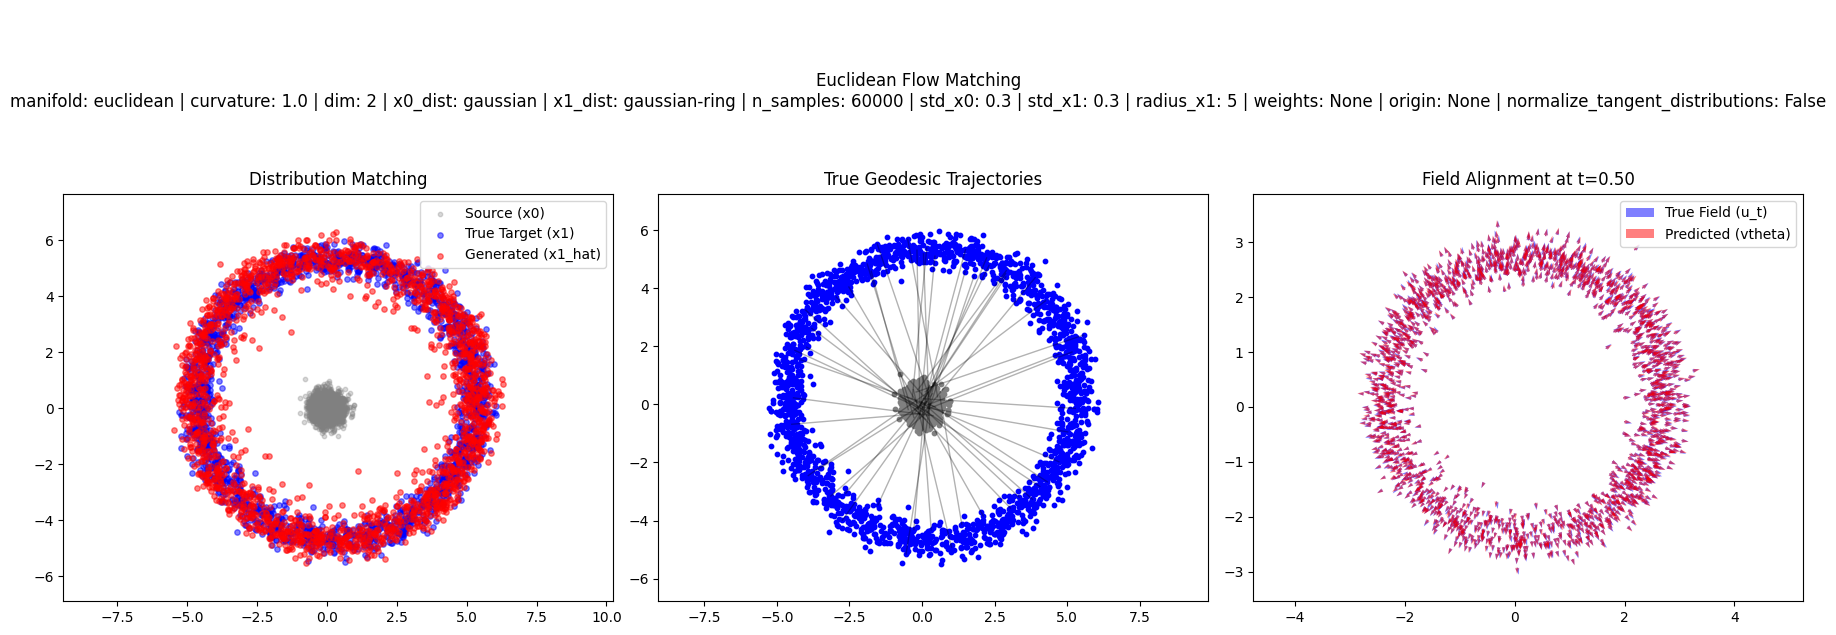

In [6]:
metrics = get_metrics(RUN_DIRS, RUN_GLOBS, OUT_DIR, default_metrics=DEFAULT_METRICS)
df = pd.DataFrame(metrics)

Available metrics:
train/loss, train/loss_step, train/loss_epoch, lr-AdamW, nfe, integ_error, val/rfm_loss, val/rfm_loss_epoch, val/loss, val/loss_epoch, val/loss_best, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/mmd, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_

,curvature,val/rfm_loss
general__sph_d512_c10_n5_wu,10.0,0.000269


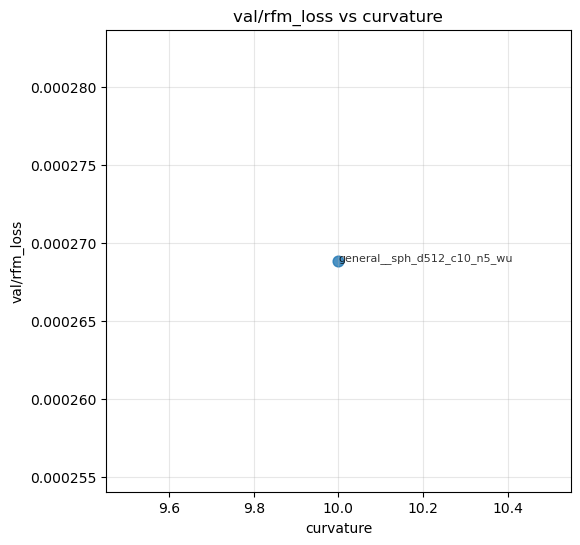

In [31]:
print("Available metrics:")
print(", ".join(map(str, df.index.tolist())))
# df has: rows = metric names, columns = runs (datapoints).
# pick any two rows to compare across runs:
x_metric = 'curvature'
y_metric = 'val/rfm_loss'

fig, ax, plotted = plot_rows_scatter(
    df,
    df.index.get_loc(x_metric),
    df.index.get_loc(y_metric),
    scatter_kwargs={"s": 60, "alpha": 0.8},
    label_points=True,
)

plotted.sort_values([x_metric, y_metric]).head()

Missing runs:
  d1024_c1
  d1024_c2
  d1024_c3
  d1024_c4
  d1024_c5
  d1024_c6
  d1024_c7
  d1024_c8
  d1024_c9
  d1024_c10


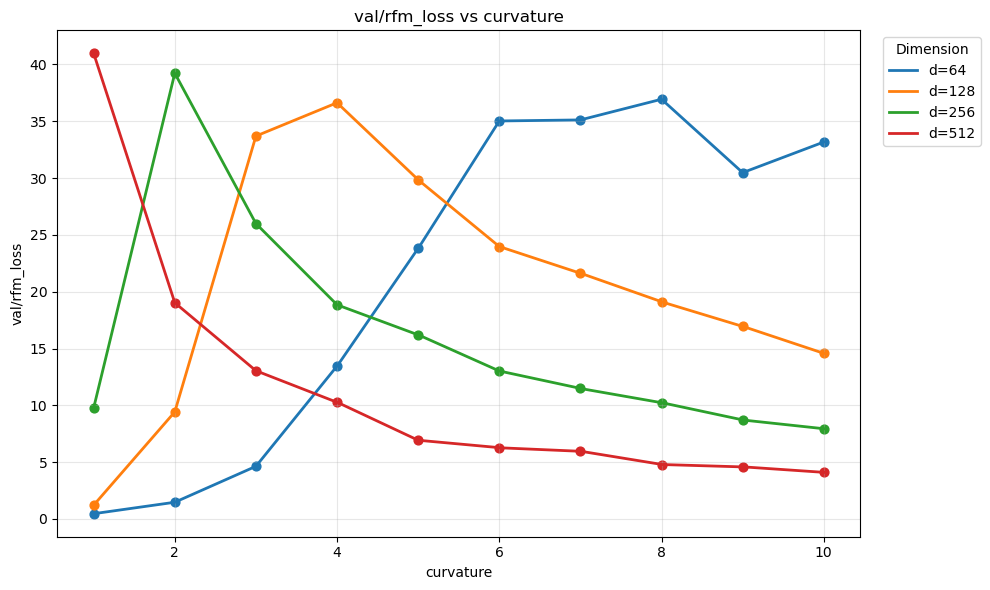

,dim,curvature,val/rfm_loss
general__poi_d64_c1,64,1.0,0.459231
general__poi_d64_c2,64,2.0,1.468271
general__poi_d64_c3,64,3.0,4.632004
general__poi_d64_c4,64,4.0,13.443078
general__poi_d64_c5,64,5.0,23.804079
general__poi_d64_c6,64,6.0,35.028080
general__poi_d64_c7,64,7.0,35.120426
general__poi_d64_c8,64,8.0,36.941196
general__poi_d64_c9,64,9.0,30.478573
general__poi_d64_c10,64,10.0,33.175880


In [24]:
import numpy as np
dims_to_plot = [64, 128, 256, 512, 1024]
curvatures_to_plot = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # 0.5 excluded by default

# remove_curvature = 0.5
smooth = True
smooth_points = 1000  # resolution of smooth curve

# ------------------------------------------------------------
# Prepare dataframe
# ------------------------------------------------------------
plot_df = df.T.copy()

plot_df["dim"] = pd.to_numeric(plot_df["dim"])
plot_df["curvature"] = pd.to_numeric(plot_df["curvature"])
plot_df["val/rfm_loss"] = pd.to_numeric(plot_df["val/rfm_loss"])

# Remove unwanted curvature globally
# plot_df = plot_df[plot_df["curvature"] != remove_curvature]

# Filter by user selection
plot_df = plot_df[
    plot_df["dim"].isin(dims_to_plot) &
    plot_df["curvature"].isin(curvatures_to_plot)
]

# ------------------------------------------------------------
# Check missing runs
# ------------------------------------------------------------
existing = set(zip(plot_df["dim"], plot_df["curvature"]))

missing = [
    f"d{d}_c{c}"
    for d in dims_to_plot
    for c in curvatures_to_plot
    if (d, float(c)) not in existing
]

if missing:
    print("Missing runs:")
    for m in missing:
        print(" ", m)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
x_metric = "curvature"
y_metric = "val/rfm_loss"

fig, ax = plt.subplots(figsize=(10, 6))

for dim in sorted(plot_df["dim"].unique()):
    subdf = plot_df[plot_df["dim"] == dim].sort_values(x_metric)

    if len(subdf) == 0:
        continue

    x = subdf[x_metric].values
    y = subdf[y_metric].values

    # --------------------------------------------------------
    # Smooth curve (optional)
    # --------------------------------------------------------
    if smooth and len(x) > 1:
        x_new = np.linspace(x.min(), x.max(), smooth_points)
        y_new = np.interp(x_new, x, y)  # simple linear interpolation

        ax.plot(x_new, y_new, linewidth=2, label=f"d={int(dim)}")
        ax.scatter(x, y, s=40)
    else:
        ax.plot(x, y, marker="o", linewidth=2, label=f"d={int(dim)}")

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
ax.set_xlabel(x_metric)
ax.set_ylabel(y_metric)
ax.set_title(f"{y_metric} vs {x_metric}")
ax.grid(True, alpha=0.3)

ax.legend(
    title="Dimension",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Inspect
# ------------------------------------------------------------

plot_df.sort_values(["dim", "curvature"])[
    ["dim", "curvature", "val/rfm_loss"]
].head(20)